In [2]:
"""
***************************************
              First Step  -Testing the Code on one Function
***************************************
"""

import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel

# Load files
X = np.load("function3_inputs.npy")
y = np.load("function3_outputs.npy")

print("Inputs shape:", X.shape)
print("Outputs shape:", y.shape)

# ============================
# ADD WEEK 1 RETURNED POINT
# ============================
week1_point = np.array([0.522581, 0.591593, 0.350176])
week1_output = -0.04757757182509677  # ✅ Correct for Function 3

if len(week1_point) != X.shape[1]:
    raise ValueError(f"Dimension mismatch: expected {X.shape[1]}, got {len(week1_point)}")

# Append if not exists
if not np.any(np.all(np.isclose(X, week1_point.reshape(1, -1)), axis=1)):
    X = np.vstack([X, week1_point])
    y = np.append(y, week1_output)

print("\nUpdated dataset size:", X.shape)

# ============================
# BEST CURRENT POINT
# ============================
best_index = np.argmax(y)
best_input = X[best_index]
best_output = y[best_index]

print("\nBest input:", best_input)
print("Best output:", best_output)

# ============================
# GAUSSIAN PROCESS MODEL
# ============================
kernel = (
    ConstantKernel(1.0) *
    RBF(length_scale=np.ones(X.shape[1])) +
    WhiteKernel(noise_level=1e-5)
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=5,
    random_state=42
)

gp.fit(X, y)

print("\nGP model trained.")

# ============================
# GENERATE CANDIDATES
# ============================
np.random.seed(42)

candidates = np.random.uniform(0, 1, size=(5000, X.shape[1]))

#  Add local exploration (important upgrade)
local_noise = np.random.normal(0, 0.05, size=(1000, X.shape[1]))
local_candidates = np.clip(best_input + local_noise, 0, 1)

candidates = np.vstack([candidates, local_candidates])

# ============================
# ACQUISITION FUNCTION (UCB)
# ============================
beta = 2.5

mu, sigma = gp.predict(candidates, return_std=True)
ucb = mu + beta * sigma

best_candidate_index = np.argmax(ucb)
new_point = candidates[best_candidate_index]

# ============================
# FINAL STEP
# ============================
new_point = np.clip(new_point, 0, 1)

print("\nNew point:", new_point)
print("Predicted mean:", mu[best_candidate_index])
print("Predicted std:", sigma[best_candidate_index])

query_string = "-".join([f"{value:.6f}" for value in new_point])

print("\n Week (2) - FINAL SUBMISSION:")
print(query_string)

Inputs shape: (15, 3)
Outputs shape: (15,)

Updated dataset size: (16, 3)

Best input: [0.49258141 0.61159319 0.34017639]
Best output: -0.034835313350078584

GP model trained.

New point: [7.79820884e-01 1.18218622e-01 3.07188454e-05]
Predicted mean: -0.04671712217165685
Predicted std: 0.07043856039715166

 Week (2) - FINAL SUBMISSION:
0.779821-0.118219-0.000031


In [3]:
"""
***************************************
              Final Code - For all Functions (Week 2)
***************************************
"""

import numpy as np
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel

np.random.seed(42)

functions_config = {
    1: {"week1_point": [0.761024, 0.713000], "week1_output": -7.565331332744927e-18},
    2: {"week1_point": [0.732637, 0.906564], "week1_output": 0.5530064492925906},
    3: {"week1_point": [0.522581, 0.591593, 0.350176], "week1_output": -0.03333218343962805},
    4: {"week1_point": [0.564020, 0.473834, 0.390972, 0.258427], "week1_output": -4.83054096204485},
    5: {"week1_point": [0.196777, 0.892275, 0.855813, 0.891829], "week1_output": 1257.680268889983},
    6: {"week1_point": [0.728785, 0.146949, 0.767044, 0.739699, 0.020789], "week1_output": -0.8072367077314392},
    7: {"week1_point": [0.016700, 0.532618, 0.280647, 0.222769, 0.407487, 0.748018], "week1_output": 1.2394822144938658},
    8: {"week1_point": [0.035844, 0.064098, 0.010711, 0.024463, 0.361511, 0.783344, 0.515157, 0.880442], "week1_output": 9.5430069620611},
}

all_results = []

for func_id, config in functions_config.items():

    print("\n" + "="*50)
    print(f"Function {func_id}")
    print("="*50)

    # FIXED LOADING
    X = np.load(f"function{func_id}_inputs.npy")
    y = np.load(f"function{func_id}_outputs.npy")

    week1_point = np.array(config["week1_point"]).flatten()
    week1_output = config["week1_output"]

    # Safety check
    if len(week1_point) != X.shape[1]:
        raise ValueError(f"Function {func_id}: Dimension mismatch")

    # Append Week 1 point
    if not np.any(np.all(np.isclose(X, week1_point.reshape(1, -1)), axis=1)):
        X = np.vstack([X, week1_point])
        y = np.append(y, week1_output)

    print("Dataset size:", X.shape)

    # Best point
    best_index = np.argmax(y)
    best_input = X[best_index]
    best_output = y[best_index]

    print("Best output:", best_output)

    # Strategy adaptation
    dim = X.shape[1]

    if dim <= 3:
        beta = 1.5
        n_candidates = 5000
        noise_scale = 0.03
    elif dim <= 5:
        beta = 2.0
        n_candidates = 8000
        noise_scale = 0.05
    else:
        beta = 2.5
        n_candidates = 12000
        noise_scale = 0.08

    # Gaussian Process
    kernel = (
        ConstantKernel(1.0) *
        RBF(length_scale=np.ones(dim), length_scale_bounds=(1e-2, 1e2)) +
        WhiteKernel(noise_level=1e-5)
    )

    gp = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=5,
        random_state=42
    )

    gp.fit(X, y)

    # Candidates
    candidates = np.random.uniform(0, 1, size=(n_candidates, dim))

    local_noise = np.random.normal(0, noise_scale, size=(1000, dim))
    local_candidates = np.clip(best_input + local_noise, 0, 1)

    candidates = np.vstack([candidates, local_candidates])

    # UCB
    mu, sigma = gp.predict(candidates, return_std=True)
    ucb = mu + beta * sigma

    best_idx = np.argmax(ucb)
    new_point = candidates[best_idx]

    # Final formatting
    new_point = np.clip(new_point, 0, 1)

    query_string = "-".join([f"{value:.6f}" for value in new_point])

    print("New point:", new_point)
    print("FINAL SUBMISSION:", query_string)

    all_results.append({
        "Function": func_id,
        "Dimension": dim,
        "Best_Output": best_output,
        "Submission": query_string,
        "Beta": beta
    })

# Save results
df = pd.DataFrame(all_results)
df.to_csv("Week2_Submissions.csv", index=False)

print("\nAll submissions saved to Week2_Submissions.csv")


Function 1
Dataset size: (11, 2)
Best output: 7.710875114502849e-16


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


New point: [0.75182515 0.81194623]
FINAL SUBMISSION: 0.751825-0.811946

Function 2
Dataset size: (11, 2)
Best output: 0.6112052157614438


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


New point: [0.98081658 0.62671508]
FINAL SUBMISSION: 0.980817-0.626715

Function 3
Dataset size: (16, 3)
Best output: -0.03333218343962805


...

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


New point: [0.52127841 0.5051385  0.98547268 0.99454507]
FINAL SUBMISSION: 0.521278-0.505138-0.985473-0.994545

Function 6
Dataset size: (21, 5)
Best output: -0.7142649478202404
New point: [0.3411551  0.02127846 0.62648659 0.97066054 0.03276188]
FINAL SUBMISSION: 0.341155-0.021278-0.626487-0.970661-0.032762

Function 7
Dataset size: (31, 6)
Best output: 1.3649683044991994


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


New point: [0.43139012 0.17387896 0.07133947 0.12447302 0.40359186 0.62417963]
FINAL SUBMISSION: 0.431390-0.173879-0.071339-0.124473-0.403592-0.624180

Function 8
Dataset size: (41, 8)
Best output: 9.598482002566342
New point: [0.06421429 0.41279267 0.08158871 0.00819471 0.97443794 0.21619563
 0.13917277 0.1106241 ]
FINAL SUBMISSION: 0.064214-0.412793-0.081589-0.008195-0.974438-0.216196-0.139173-0.110624

All submissions saved to Week2_Submissions.csv


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


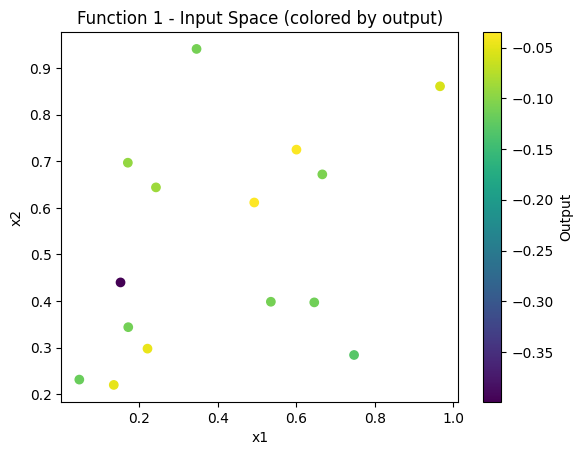

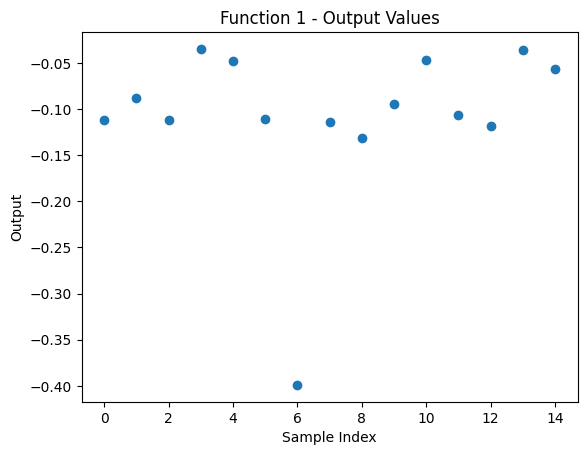

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load your data
X = np.load("function3_inputs.npy")
y = np.load("function3_outputs.npy")

# ============================
# 1. INPUT SPACE (x1 vs x2)
# ============================
plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Function 1 - Input Space (colored by output)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.colorbar(label="Output")
plt.show()

# ============================
# 2. OUTPUT DISTRIBUTION
# ============================
plt.figure()
plt.scatter(range(len(y)), y)
plt.title("Function 1 - Output Values")
plt.xlabel("Sample Index")
plt.ylabel("Output")
plt.show()

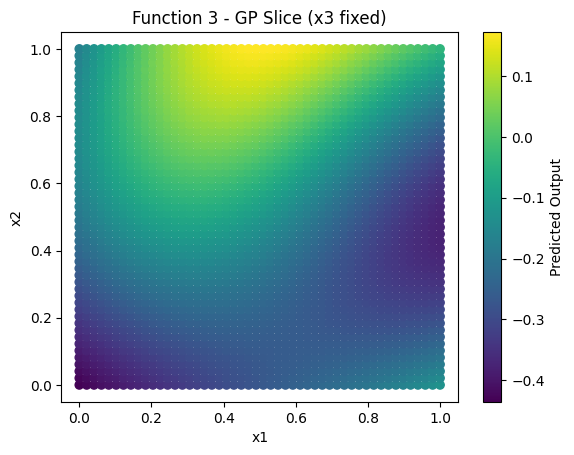

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Assume GP already trained on X (3D)

# Fix x3 at best value
fixed_x3 = best_input[2]

# Create grid for x1, x2
x1 = np.linspace(0, 1, 50)
x2 = np.linspace(0, 1, 50)

X1, X2 = np.meshgrid(x1, x2)

# Build full 3D input
grid_points = np.c_[
    X1.ravel(),
    X2.ravel(),
    np.full_like(X1.ravel(), fixed_x3)
]

# Predict
mu, sigma = gp.predict(grid_points, return_std=True)

# Plot
plt.figure()
plt.scatter(grid_points[:,0], grid_points[:,1], c=mu)
plt.title("Function 3 - GP Slice (x3 fixed)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.colorbar(label="Predicted Output")
plt.show()